In [414]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


$L = 31,5$ см

$d = 1$ см

In [415]:
# Нулевое значение
V_0 = np.float128('-0.620')

У нас кристалл паротеллурита, параметры для него из метождички

In [416]:
n_o = np.float128('2.2597')
n_e = np.float128('2.4119')

# Двулучепреломление
Delta_n = n_o - n_e
print(f"Delta_n = {Delta_n}")

# V_s
V_s = np.float128('0.52e3') # m/s


d = np.float128('1e-2')     # m
L = np.float128('31.5e-2')  # m

Delta_theta = d / L

Delta_n = -0.1522


Из методы знаем соотношение для угла


$$ \sin \theta_i = \cfrac{\lambda \nu}{\Delta n V} $$

Угол разделяющий падающий и дефрагированный лучи

$$ \Delta \theta = \cfrac{\Delta n}{2 n_o} \sin {2 \theta_i} $$

По порядку величины: $\lambda \sim 5 \cdot 10^{-9}$, $V \sim 5 \cdot 10^2$, $\Delta n \sim 1.5 \cdot 10^{-1}$, $\nu \sim 3 \cdot 10^7$, тогда



$$ \sin \theta_i \sim 2 \cdot 10^{-3} $$

Получаем

$$ \sin \theta_i \approx \theta_i, \ \ \ \sin {2\theta_i} \approx 2\theta_i $$



Подставляем

$$ \Delta \theta = \cfrac{\Delta n}{2 n_o} \cdot 2 \theta_i = \cfrac{\Delta n}{2 n_o} \cdot \cfrac{2  \lambda \nu}{\Delta n V} = \cfrac{\lambda \nu}{n_o V} $$

Тогда $\lambda$ найдем как

$$ \lambda = \cfrac{\Delta \theta n_o V}{\nu} $$

In [417]:
# Погрешность амплитуды
sigma_V = 0.003

# Погрешность частотометра
sigma_nu = 0.001


# Первое измерение

In [418]:
data_1 = pd.read_excel("data.ods", sheet_name="1")

In [419]:
data_1

,"nu, MHz","V, V",Unnamed: 2
0,25.793,-0.620,нулевое значение
1,26.392,-0.570,NaN
2,27.714,-0.025,NaN
3,27.784,0.188,NaN
4,27.853,0.221,NaN
5,27.936,0.232,NaN
6,28.001,0.245,NaN
7,28.047,0.248,NaN
8,28.064,0.249,NaN
9,28.088,0.240,NaN


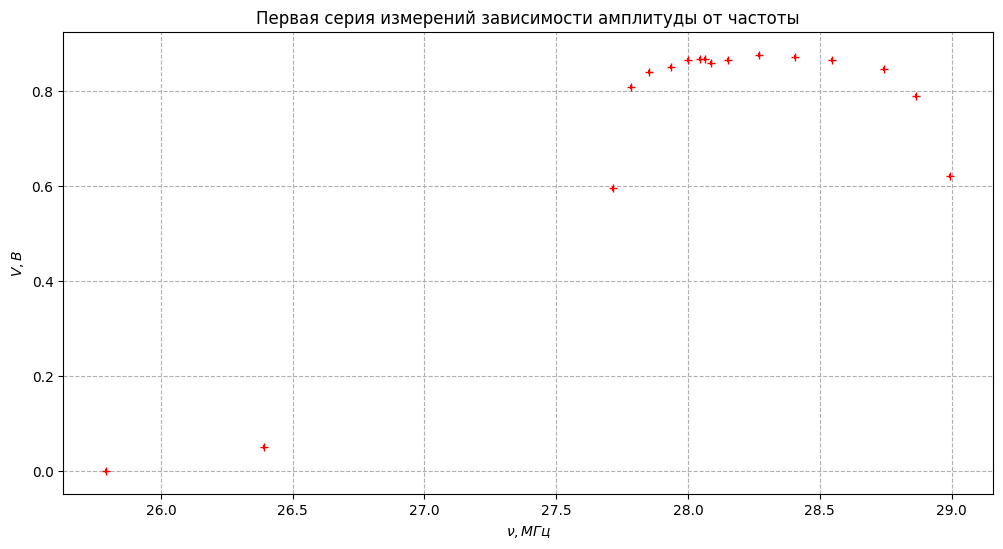

In [420]:
x = data_1["nu, MHz"]
sigma_x = sigma_V

y = data_1["V, V"] - V_0
sigma_y = np.sqrt(2) * sigma_V


plt.figure(figsize=(12, 6))

plt.grid(True, linestyle="--")

plt.errorbar(y=y, yerr=sigma_y, x=x, xerr=sigma_x, fmt="+r")

plt.title(r"Первая серия измерений зависимости амплитуды от частоты")

plt.xlabel(r"$\nu, МГц$")
plt.ylabel(r"$V, В$")

plt.savefig("pictures/amplitude_frequency_1.pdf")
plt.show()

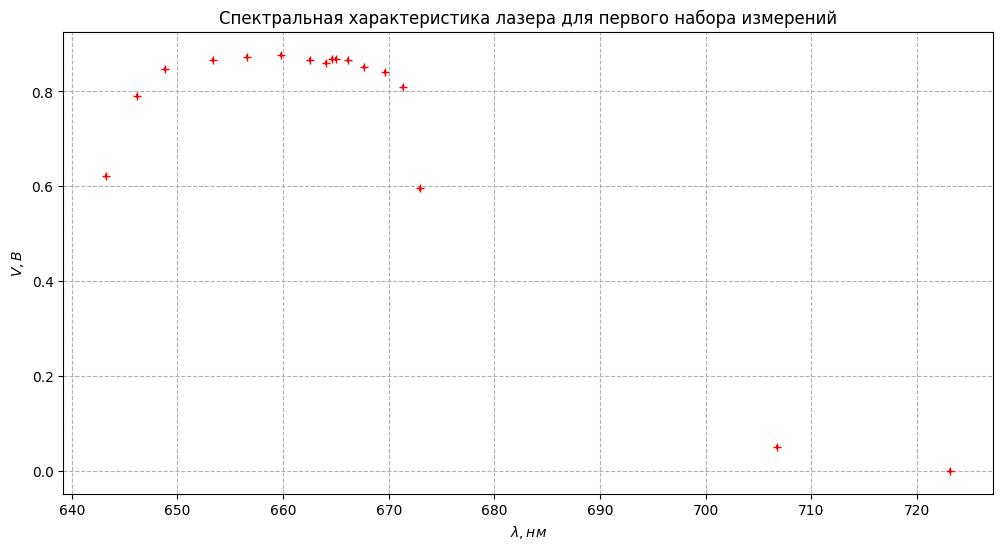

In [421]:
lambdda = 1e3 * Delta_theta * n_o * V_s / x / 2

# Относительная погрешность сохраняется
sigma_lambda = lambdda * sigma_x / x


y = data_1["V, V"] - V_0


plt.figure(figsize=(12, 6))

plt.grid(True, linestyle="--")

plt.errorbar(y=y, yerr=sigma_y, x=lambdda, xerr=sigma_lambda, fmt="+r")

plt.title(r"Спектральная характеристика лазера для первого набора измерений")

plt.xlabel(r"$\lambda, нм$")
plt.ylabel(r"$V, В$")

plt.savefig("pictures/laser_specter_1.pdf")
plt.show()

# Второе измерение

In [422]:
data_2 = pd.read_excel("data.ods", sheet_name="2")

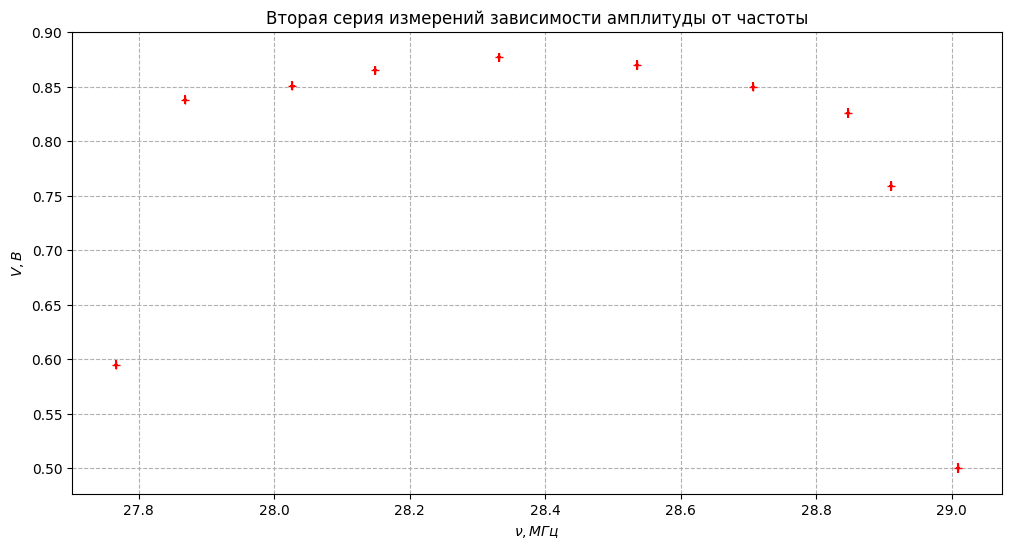

In [423]:
x = data_2["nu, MHz"]
sigma_x = sigma_V

y = data_2["V, V"] - V_0
sigma_y = np.sqrt(2) * sigma_V


plt.figure(figsize=(12, 6))


plt.grid(True, linestyle="--")

plt.title(r"Вторая серия измерений зависимости амплитуды от частоты")

plt.errorbar(y=y, yerr=sigma_y, x=x, xerr=sigma_x, fmt="+r")

plt.xlabel(r"$\nu, МГц$")
plt.ylabel(r"$V, В$")

plt.savefig("pictures/amplitude_frequency_2.pdf")
plt.show()


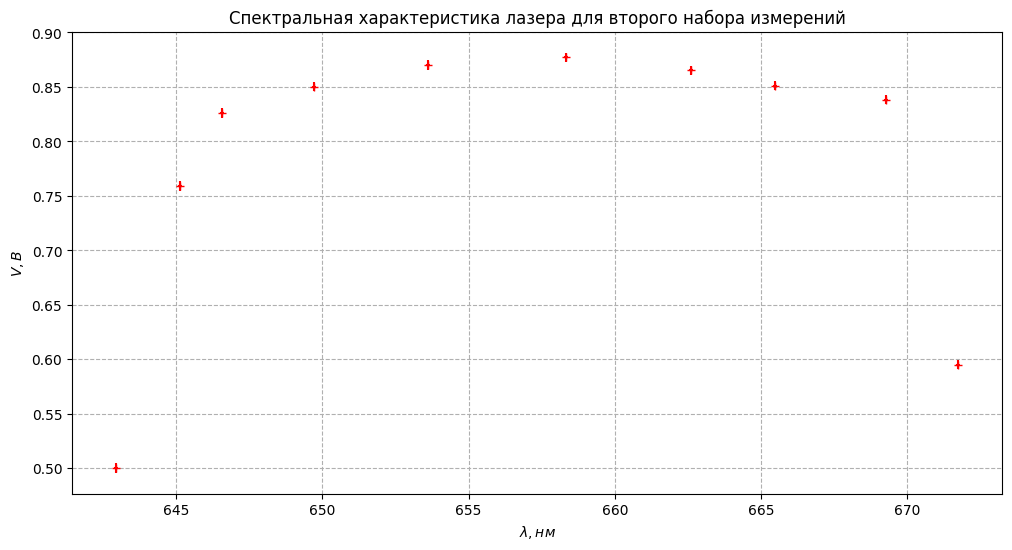

In [424]:
lambdda = 1e3 * Delta_theta * n_o * V_s / x / 2

# Относительная погрешность сохраняется
sigma_lambda = lambdda * sigma_x / x

y = data_2["V, V"] - V_0


plt.figure(figsize=(12, 6))

plt.grid(True, linestyle="--")

plt.errorbar(y=y, yerr=sigma_y, x=lambdda, xerr=sigma_lambda, fmt="+r")

plt.title(r"Спектральная характеристика лазера для второго набора измерений")

plt.xlabel(r"$\lambda, нм$")
plt.ylabel(r"$V, В$")

plt.savefig("pictures/laser_specter_2.pdf")
plt.show()

# Измерение децебел

$$ P [Вт] = 10^{\cfrac{P[Дб]}{10}} $$

In [425]:
data_3 = pd.read_excel("data.ods", sheet_name="3")

data_3["A"] = data_3["V, V"] - V_0

data_3["P"] = np.pow(10, data_3["decebel"]/10)

data_3

,decebel,"V, V",A,P
0,0,0.252,0.872,1.000000
1,1,0.248,0.868,1.258925
2,2,0.243,0.863,1.584893
3,3,0.237,0.857,1.995262
4,4,0.231,0.851,2.511886
5,5,0.222,0.842,3.162278
6,6,0.206,0.826,3.981072
7,7,0.173,0.793,5.011872
8,8,0.117,0.737,6.309573
9,9,0.040,0.660,7.943282


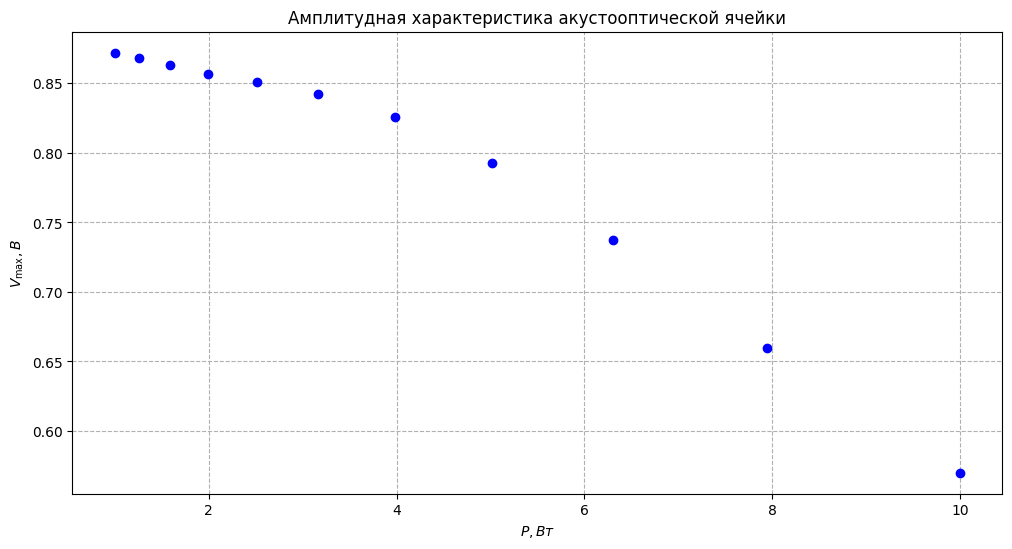

In [426]:
plt.figure(figsize=(12, 6))

plt.grid(True, linestyle="--")

plt.errorbar(x=data_3["P"], y=data_3["A"], fmt="ob")


plt.xlabel(r"$P, Вт$")
plt.ylabel(r"$V_\text{max}, В$")

plt.title("Амплитудная характеристика акустооптической ячейки")


plt.savefig("pictures/amplitude_p.pdf")

plt.show()


# Максимум от частоты

In [427]:
data_4 = pd.read_excel("data.ods", sheet_name="4")


data_4["A"] = data_4["V, V"] - V_0

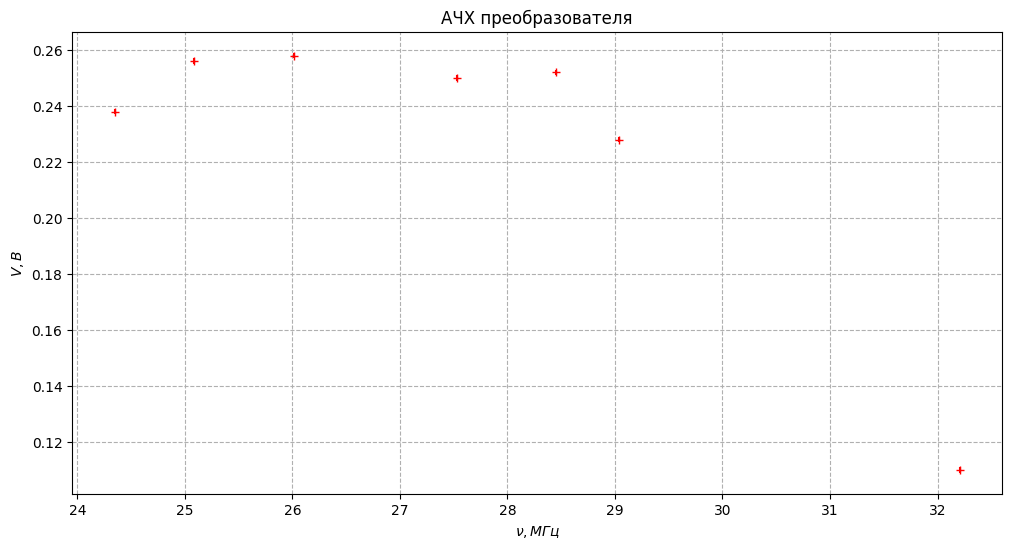

In [428]:
plt.figure(figsize=(12, 6))

plt.grid(True, linestyle="--")




plt.errorbar(y=data_4["V, V"], xerr=0.001, x=data_4["nu, MHz"], yerr=0.001, fmt="+r")


plt.xlabel(r"$\nu, МГц$")
plt.ylabel(r"$V, В$")

plt.title("АЧХ преобразователя")


plt.savefig("pictures/amplitude_frequency_characteristic.pdf")
plt.show()
